# P-Delta2 Feature Lab — Faster + More Powerful Ingredients

This Colab performs a controlled **ingredient ablation** on the strongest P-Delta2 direction. It keeps one SmolLM2 attention layer replacement isolated and asks two separate questions:

1. **Power:** which ingredient lowers held-out next-token NLL?
2. **Speed:** which ingredient reduces retrieval work / recurrent overhead without losing the quality margin?

| Ingredient | Mechanism | Intended gain |
|---|---|---|
| **Vectorized curvature preconditioner** | same P-Delta2 recurrence, parallelized inside 32-token chunks | speed without changing the math |
| **Sparse dilated exact retrieval** | exact softmax only at offsets `0,1,2,4,8,16,32` | 7 comparisons/token instead of a dense 32-token local window |
| **Dual-timescale memory** | split the recurrent feature budget into fast and slow memories and mix per query | retain both local syntax and long-range semantics |
| **Lean dual+dilated** | same ideas at feature dim 64 | quality/speed Pareto candidate |
| **torch.compile** | post-training compiler timing of the winner | implementation speed only; never used to select quality |

The benchmark keeps document-disjoint train/validation/test partitions, checks an exact-softmax replacement control, chooses winners on **validation only**, and then opens the test set.

Research motivation: recent efficient-attention work increasingly combines recurrent/linear state, sparse retrieval and chunking rather than relying on one mechanism alone. This implementation is an independent TinyCeNN experiment, not a reproduction of another model.


In [1]:
import importlib, pathlib, subprocess, sys, tempfile

REF = 'main'
WORK = pathlib.Path('/content') if pathlib.Path('/content').exists() else pathlib.Path.cwd()
REPO = pathlib.Path(tempfile.mkdtemp(prefix='TinyCeNN-feature-lab-', dir=WORK))
subprocess.run(['git','clone','--depth','1','--branch',REF,'https://github.com/vtavakkoli/TinyCeNN-LM.git',str(REPO)], check=True)
subprocess.run([sys.executable,'-m','pip','install','-q','-e',str(REPO),'transformers==4.57.6','datasets>=3,<5','pandas','matplotlib','pytest>=8'], check=True)
for p in (REPO, REPO/'src'):
    if str(p) not in sys.path: sys.path.insert(0, str(p))
importlib.invalidate_caches()
print('Commit:', subprocess.check_output(['git','-C',str(REPO),'rev-parse','--short','HEAD'], text=True).strip())


Commit: 3f5e076


## 1 · Choose the budget

Start with **balanced**. `quick` verifies the pipeline. `strong` is the useful follow-up if an ingredient clearly improves the Pareto frontier.


In [2]:
from datetime import datetime, timezone
import torch

PROFILE = 'balanced'   # quick | balanced | strong
LAYER = 18
TRAIN_CONTEXT = 256
TEST_CONTEXTS = '256,512,1024'
SEED = 2026

assert torch.cuda.is_available(), 'Select Runtime → Change runtime type → GPU'
RUN_ID = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%fZ')
OUTPUT_DIR = WORK / 'TinyCeNN-feature-results' / f'{PROFILE}-{RUN_ID}'
OUTPUT_DIR.parent.mkdir(parents=True, exist_ok=True)
print('GPU:', torch.cuda.get_device_name(0))
print('Output:', OUTPUT_DIR)


GPU: Tesla T4
Output: /content/TinyCeNN-feature-results/balanced-20260914T201834589770Z


## 2 · Numerical / causal checks

The vectorized preconditioner must match a slow tokenwise oracle; sparse retrieval must be causal; streaming must agree with full-prefix execution; and checkpoints must reconstruct.


In [3]:
subprocess.run([sys.executable,'-m','pytest','-q',str(REPO/'tests/test_pdelta2_feature_lab.py')], cwd=REPO, check=True)


CompletedProcess(args=['/usr/bin/python3', '-m', 'pytest', '-q', '/content/TinyCeNN-feature-lab-2nuox7yd/tests/test_pdelta2_feature_lab.py'], returncode=0)

## 3 · Run the ingredient screen

Balanced mode compares recurrent-only P-Delta2, dense-window controls, sparse dilated retrieval, dual-timescale memory, and combined lean/quality variants. Quality and efficient winners are locked on validation before test scoring.


In [4]:
cmd = [
    sys.executable, str(REPO/'scripts/benchmark_pdelta2_feature_lab.py'),
    '--profile', PROFILE, '--layer', str(LAYER),
    '--train-context', str(TRAIN_CONTEXT), '--test-contexts', TEST_CONTEXTS,
    '--seed', str(SEED), '--output-dir', str(OUTPUT_DIR),
]
print(' '.join(cmd))
subprocess.run(cmd, cwd=REPO, check=True)


/usr/bin/python3 /content/TinyCeNN-feature-lab-2nuox7yd/scripts/benchmark_pdelta2_feature_lab.py --profile balanced --layer 18 --train-context 256 --test-contexts 256,512,1024 --seed 2026 --output-dir /content/TinyCeNN-feature-results/balanced-20260914T201834589770Z


CompletedProcess(args=['/usr/bin/python3', '/content/TinyCeNN-feature-lab-2nuox7yd/scripts/benchmark_pdelta2_feature_lab.py', '--profile', 'balanced', '--layer', '18', '--train-context', '256', '--test-contexts', '256,512,1024', '--seed', '2026', '--output-dir', '/content/TinyCeNN-feature-results/balanced-20260914T201834589770Z'], returncode=0)

## 4 · Results dashboard

- **Lower ΔNLL** = stronger language-model quality.
- **Lower decode/prefill ms** = faster reference implementation.
- **Lower state/KV ratio** = better persistent-memory scaling.
- `memory_efficient_parity` means the paired interval stays inside ±0.02 nats while persistent state is under 50% of Transformer FP16 KV state.


Selection: {'quality_winner': 'pdelta2_none_f96', 'efficient_winner': 'pdelta2_none_f96', 'quality_criterion': 'lowest validation NLL', 'efficiency_criterion': 'lowest measured decode-step time among validation candidates within NLL margin', 'test_not_used_for_selection': True}


,name,feature_dim,retrieval,window,offsets,dual_timescale,ingredient,validation_nll,validation_delta_nll,validation_ppl,output_nmse,output_cosine,trainable_parameters,retrieval_pairs_per_token,state_bytes,state_vs_transformer_fp16,prefill_ms,decode_step_ms,prefill_speedup_vs_transformer,decode_speedup_vs_transformer
0,pdelta2_none_f96,96,none,1,[0],False,recurrent_only,2.915487,0.012347,18.457802,0.379356,0.697501,124239,0,74880,0.380859,11.512383,2.327896,0.011367,0.055037
1,pdelta2_dual_none_f96,96,none,1,[0],True,dual_timescale_memory,2.916476,0.013336,18.476062,0.374437,0.684431,137319,0,74880,0.380859,22.258369,4.799175,0.007269,0.026178
2,pdelta2_dense64_f128,128,dense,64,[0],False,previous_quality_control,2.918960,0.015820,18.522017,0.317397,0.713053,162072,64,196608,1.000000,11.950583,3.325631,0.010890,0.057738
3,pdelta2_dense32_f96,96,dense,32,[0],False,dense_local_retrieval,2.920663,0.017524,18.553592,0.372453,0.677563,124824,32,122496,0.623047,12.643103,4.990945,0.017896,0.042746
4,pdelta2_dilated32_f128,128,dilated,1,"[0, 1, 2, 4, 8, 16, 32]",False,sparse_dilated_plus_capacity,2.924912,0.021772,18.632588,0.480463,0.593183,162072,7,148992,0.757812,12.400911,3.205360,0.010834,0.041036
5,pdelta2_dual_dilated32_f64,64,dilated,1,"[0, 1, 2, 4, 8, 16, 32]",True,speed_lean_combo,2.925049,0.021909,18.635141,0.491957,0.603118,100656,7,99072,0.503906,23.765591,5.616633,0.005721,0.022726
6,pdelta2_dilated32_f96,96,dilated,1,"[0, 1, 2, 4, 8, 16, 32]",False,sparse_dilated_retrieval,2.925289,0.022149,18.639605,0.482022,0.593426,124824,7,124032,0.630859,11.905091,3.138421,0.017404,0.040140
7,pdelta2_dual_dilated32_f96,96,dilated,1,"[0, 1, 2, 4, 8, 16, 32]",True,dual_timescale_plus_dilated,2.926174,0.023034,18.656115,0.485240,0.606302,137904,7,124032,0.630859,24.103143,5.646691,0.005527,0.022776


,name,feature_dim,retrieval,window,offsets,dual_timescale,ingredient,context,selected_quality,selected_efficient,...,candidate_ppl,transformer_ppl,ppl_ratio,delta_nll,ci95_low,ci95_high,state_bytes,transformer_kv_bytes_fp16,state_vs_transformer_fp16,verdict
0,pdelta2_none_f96,96,none,1,[0],False,recurrent_only,256,True,True,...,17.529200,17.322305,1.011944,0.011873,0.007712,0.016478,74880,196608,0.380859,memory_efficient_parity
1,pdelta2_dual_none_f96,96,none,1,[0],True,dual_timescale_memory,256,False,False,...,17.540649,17.322305,1.012605,0.012526,0.008339,0.017237,74880,196608,0.380859,memory_efficient_parity
2,pdelta2_dense64_f128,128,dense,64,[0],False,previous_quality_control,256,False,False,...,17.545801,17.322305,1.012902,0.012820,0.008932,0.017111,196608,196608,1.000000,within_declared_nll_margin
3,pdelta2_dense32_f96,96,dense,32,[0],False,dense_local_retrieval,256,False,False,...,17.640395,17.322305,1.018363,0.018196,0.013608,0.023131,122496,196608,0.623047,inconclusive
4,pdelta2_dilated32_f128,128,dilated,1,"[0, 1, 2, 4, 8, 16, 32]",False,sparse_dilated_plus_capacity,256,False,False,...,17.728433,17.322305,1.023445,0.023175,0.017363,0.029025,148992,196608,0.757812,inconclusive
5,pdelta2_dilated32_f96,96,dilated,1,"[0, 1, 2, 4, 8, 16, 32]",False,sparse_dilated_retrieval,256,False,False,...,17.751015,17.322305,1.024749,0.024448,0.018755,0.030179,124032,196608,0.630859,inconclusive
6,pdelta2_dual_dilated32_f96,96,dilated,1,"[0, 1, 2, 4, 8, 16, 32]",True,dual_timescale_plus_dilated,256,False,False,...,17.753277,17.322305,1.024880,0.024575,0.018653,0.030504,124032,196608,0.630859,inconclusive
7,pdelta2_dual_dilated32_f64,64,dilated,1,"[0, 1, 2, 4, 8, 16, 32]",True,speed_lean_combo,256,False,False,...,17.764760,17.322305,1.025543,0.025222,0.019030,0.031268,99072,196608,0.503906,inconclusive
8,pdelta2_none_f96,96,none,1,[0],False,recurrent_only,512,True,True,...,16.779108,16.566579,1.012829,0.012747,0.010045,0.015618,74880,393216,0.190430,memory_efficient_parity
9,pdelta2_dense64_f128,128,dense,64,[0],False,previous_quality_control,512,False,False,...,16.837636,16.566579,1.016362,0.016229,0.012199,0.020735,196608,393216,0.500000,inconclusive


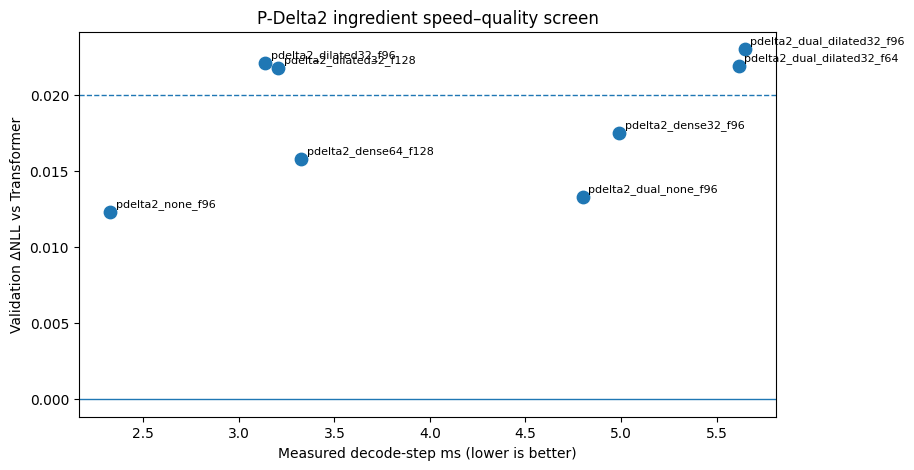

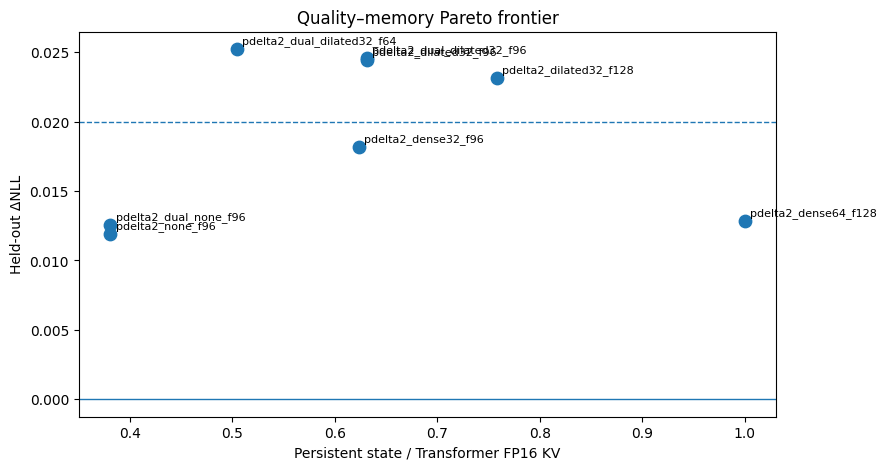

Winner diagnostics:
{
  "grad_q_cosine": 0.3807281255722046,
  "grad_q_nmse": 0.8553071022033691,
  "grad_k_cosine": 0.18186882138252258,
  "grad_k_nmse": 0.9688733220100403,
  "grad_v_cosine": 0.321872353553772,
  "grad_v_nmse": 0.9185651540756226,
  "grad_mean_cosine": 0.2948231001694997,
  "prefill_ms": 11.634300499963501,
  "transformer_prefill_ms": 0.13003599997318815,
  "prefill_speedup": 0.011176950429774107,
  "decode_step_ms": 2.3268910000524556,
  "transformer_decode_step_ms": 0.12879949997568474,
  "decode_speedup": 0.05535261427062169,
  "peak_extra_bytes": 5305344,
  "transformer_peak_extra_bytes": 1769472,
  "state_bytes_fp32": 74880,
  "transformer_kv_bytes_fp32": 393216,
  "transformer_kv_bytes_fp16": 196608,
  "state_vs_transformer_fp32": 0.1904296875,
  "state_vs_transformer_fp16": 0.380859375,
  "break_even_tokens_vs_fp16": 98,
  "timing_repeats": 10,
  "serial_preconditioner_ms": 61.378453999850535,
  "vectorized_preconditioner_ms": 5.252030999827184,
  "preconditio

In [5]:
import json, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display

val = pd.read_csv(OUTPUT_DIR/'validation_summary.csv')
test = pd.read_csv(OUTPUT_DIR/'test_summary.csv')
report = json.loads((OUTPUT_DIR/'feature_lab_report.json').read_text())
print('Selection:', report['selection'])
display(val.round(6))
display(test.round(6))

base = test[test.context == TRAIN_CONTEXT].copy()
fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(val.decode_step_ms, val.validation_delta_nll, s=80)
for _, row in val.iterrows():
    ax.annotate(row['name'], (row.decode_step_ms, row.validation_delta_nll), xytext=(4,4), textcoords='offset points', fontsize=8)
ax.axhline(0, linewidth=1)
ax.axhline(0.02, linewidth=1, linestyle='--')
ax.set_xlabel('Measured decode-step ms (lower is better)')
ax.set_ylabel('Validation ΔNLL vs Transformer')
ax.set_title('P-Delta2 ingredient speed–quality screen')
plt.show()

fig, ax = plt.subplots(figsize=(9,5))
ax.scatter(base.state_vs_transformer_fp16, base.delta_nll, s=80)
for _, row in base.iterrows():
    ax.annotate(row['name'], (row.state_vs_transformer_fp16, row.delta_nll), xytext=(4,4), textcoords='offset points', fontsize=8)
ax.axhline(0, linewidth=1); ax.axhline(0.02, linewidth=1, linestyle='--')
ax.set_xlabel('Persistent state / Transformer FP16 KV')
ax.set_ylabel('Held-out ΔNLL')
ax.set_title('Quality–memory Pareto frontier')
plt.show()

print('Winner diagnostics:')
print(json.dumps(report['winner_diagnostics'], indent=2))


## 5 · How to interpret the ingredients

The important comparisons are:

- `pdelta2_dense32_f96` **vs** `pdelta2_dilated32_f96`: does 7-point logarithmic retrieval preserve quality while reducing attention work?
- `pdelta2_none_f96` **vs** `pdelta2_dual_none_f96`: does a fast+slow memory improve recurrence without exact retrieval?
- `pdelta2_dilated32_f96` **vs** `pdelta2_dual_dilated32_f96`: does the two-timescale memory add useful power on top of sparse retrieval?
- `pdelta2_dual_dilated32_f64`: can we shrink the recurrent feature budget and still remain inside the quality margin?
- `preconditioner_speedup` and `compile_speedup`: implementation gains that should not alter the model's quality.

A result is especially interesting if it moves **down and left** on the plots: lower NLL **and** lower runtime/state.


## 6 · Package and download the complete run

The ZIP contains validation/test CSVs, training history, selection, report and all candidate checkpoints.


In [6]:
import shutil
archive = shutil.make_archive(str(OUTPUT_DIR), 'zip', root_dir=OUTPUT_DIR)
print('Archive:', archive)
try:
    from google.colab import files
    files.download(archive)
except Exception as exc:
    print('Automatic browser download is Colab-only:', exc)


Archive: /content/TinyCeNN-feature-results/balanced-20260914T201834589770Z.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>